# Bandit Problem

In [23]:
# imports
from bandits import Bandit
import random
import numpy as np
import matplotlib.pyplot as plt
# Include your imports here, if any are used. 

n=10
t=100000

A list of ten bandit objects initialized in the list...

In [24]:
bandits = [Bandit(random.random()*4-2) for _ in range(n)] # Create a list of 10 bandits with mean between -2 and 2

In [25]:
bandits[0].pullLever()

-0.31621811030003893

## Greedy algorithm Implementation

In [26]:
def run_greedy():
    averages=np.ones(n); #optimistic initialization for greedy approach
    no_of_times=np.zeros(n) #count of number of times each bandit is played
    cum_avg=[] #list of cumulative average rewards
    total=0
    for _ in range(t):
        best_actions = np.flatnonzero(averages==averages.max())
        action = np.random.choice(best_actions)
        reward=bandits[action].pullLever()
        total+=reward
        no_of_times[action]+=1
        averages[action]+=(reward-averages[action])/no_of_times[action]
        cum_avg.append(total/(_+1))
    return cum_avg


Plot the cumulative average of rewards as the number of iterations increases.

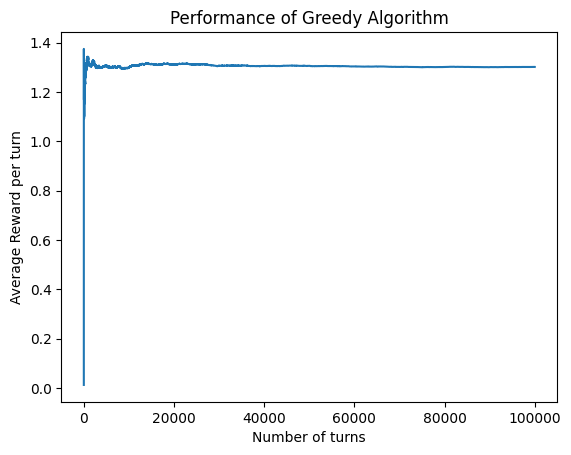

In [27]:
plt.plot(run_greedy())
plt.xlabel("Number of turns")
plt.ylabel("Average Reward per turn")
plt.title("Performance of Greedy Algorithm")
plt.show()

## $\epsilon$-greedy Algorithm

In [28]:
def run_epsilon_greedy(eps):
    total=0
    averages=np.zeros(n); #initialization
    no_of_times=np.zeros(n) #count of number of times each bandit is played
    cum_avg=[] #list of cumulative average rewards
    for _ in range(t):
        if(np.random.rand()<eps):
            action=np.random.randint(0,n)
        else:
            best_actions = np.flatnonzero(averages==averages.max())
            action=np.random.choice(best_actions)
        reward=bandits[action].pullLever()
        total+=reward
        no_of_times[action]+=1
        averages[action]+=(reward-averages[action])/no_of_times[action]
        cum_avg.append(total/(_+1))
    return cum_avg

Plot the cumulative average of rewards as the number of iterations increases but for various values of $\epsilon$.

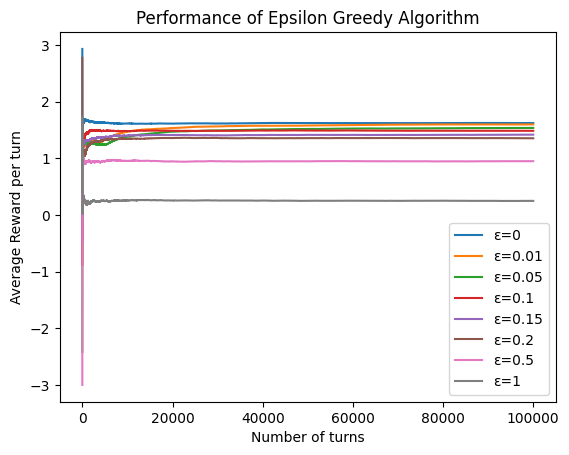

In [29]:
for eps in [0,0.01,0.05,0.1,0.15,0.2,0.5,1]:
    plt.plot(run_epsilon_greedy(eps), label=("ε="+str(eps)))
plt.xlabel("Number of turns")
plt.ylabel("Average Reward per turn")
plt.title("Performance of Epsilon Greedy Algorithm")
plt.legend()
plt.show()


## Finding the optimal $\epsilon$

Run the $\epsilon$-greedy algorithm for 1000 iterations and find the optimal $\epsilon$ value by plotting the cumulative average of rewards for various values of $\epsilon$

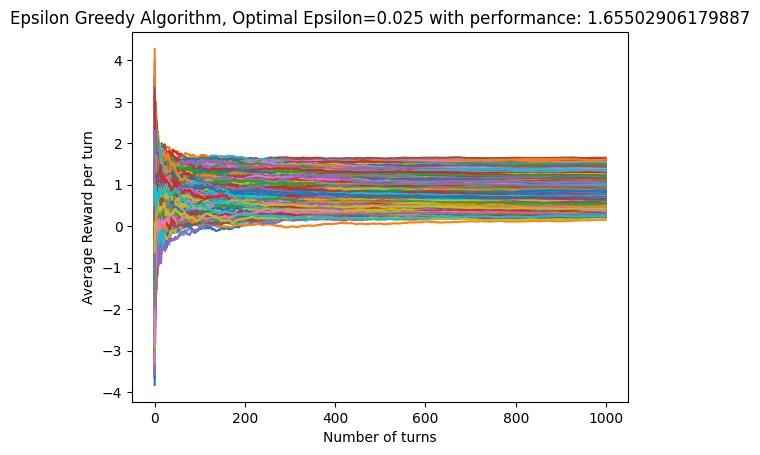

In [30]:
t=1000
performance=[]
for eps in np.linspace(0, 1, 1000):
    current=run_epsilon_greedy(eps)
    performance.append(current[-1])
    plt.plot(current)
plt.xlabel("Number of turns")
plt.ylabel("Average Reward per turn")
plt.title("Epsilon Greedy Algorithm, Optimal Epsilon="+str(np.argmax(performance)/1000)+" with performance: "+str(np.max(performance)))
plt.show()

## Optimistic Initial Values

In [31]:
t=100000
def run_optimistic_greedy():
    averages=10*np.ones(n); #optimistic initialization for greedy approach
    no_of_times=np.zeros(n) #count of number of times each bandit is played
    cum_avg=[] #list of cumulative average rewards
    total=0
    for _ in range(t):
        best_actions = np.flatnonzero(averages==averages.max())
        action = np.random.choice(best_actions)
        reward=bandits[action].pullLever()
        total+=reward
        no_of_times[action]+=1
        averages[action]+=(reward-averages[action])/no_of_times[action]
        cum_avg.append(total/(_+1))
    return cum_avg


Plot the cumulative average of rewards as the number of iterations increases for an optimistic greedy of $Q_1 = 10$ and a non-optimistic $\epsilon = 0.1$

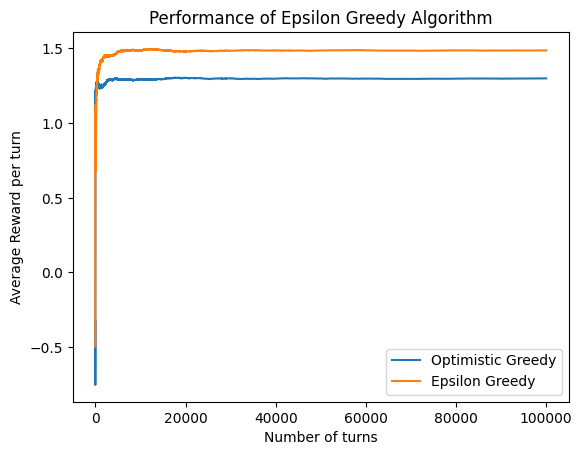

In [32]:
plt.plot(run_optimistic_greedy(),label="Optimistic Greedy")
plt.plot(run_epsilon_greedy(0.1),label="Epsilon Greedy")
plt.xlabel("Number of turns")
plt.ylabel("Average Reward per turn")
plt.title("Performance of Epsilon Greedy Algorithm")
plt.legend()
plt.show()

## Optional - Upper Confidence Bound (UCB)

In [33]:
def run_upper_confidence_bound():
    total=0
    c=2
    averages=np.zeros(n); #initialization
    no_of_times=np.zeros(n) #count of number of times each bandit is played
    cum_avg=[] #list of cumulative average rewards
    for i in range(n):
        reward=bandits[i].pullLever()
        averages[i]=reward
        no_of_times[i]=1
        total+=reward
        cum_avg.append(total/(i+1))

    for _ in range(n, t):  # start from n since we already pulled each arm once
        ucb=averages+np.sqrt(c*np.log(t+1)/no_of_times)
        best_actions = np.flatnonzero(ucb==ucb.max())
        action=np.random.choice(best_actions)
        reward=bandits[action].pullLever()
        total+=reward
        no_of_times[action]+=1
        averages[action]+=(reward-averages[action])/no_of_times[action]
        cum_avg.append(total/(_+1))
    return cum_avg

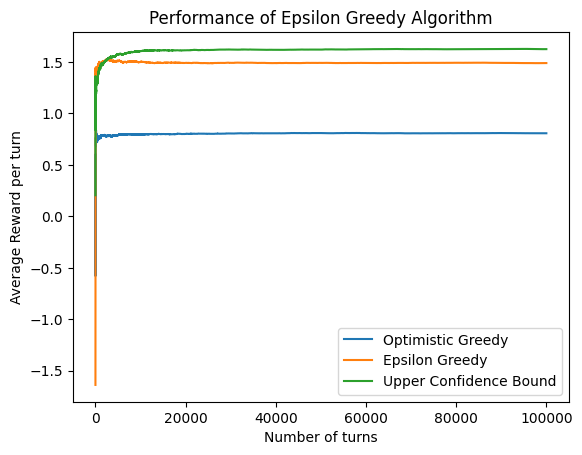

In [34]:
plt.plot(run_optimistic_greedy(),label="Optimistic Greedy")
plt.plot(run_epsilon_greedy(0.1),label="Epsilon Greedy")
plt.plot(run_upper_confidence_bound(),label="Upper Confidence Bound")
plt.xlabel("Number of turns")
plt.ylabel("Average Reward per turn")
plt.title("Performance of Epsilon Greedy Algorithm")
plt.legend()
plt.show()